In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 绘图中文配置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取全部原始数据集
clients = pd.read_csv('clients.csv', encoding='gbk')
accounts = pd.read_csv('accounts.csv', encoding='gbk')
disp = pd.read_csv('disp.csv', encoding='gbk')
loans = pd.read_csv('loans.csv', encoding='gbk')
card = pd.read_csv('card.csv', encoding='gbk')
trans = pd.read_csv('trans.csv', encoding='gbk')
order = pd.read_csv('order.csv', encoding='gbk')
district = pd.read_csv('district.csv', encoding='gbk')

# 全部日期字段转为datetime格式
clients['birth_date'] = pd.to_datetime(clients['birth_date'], errors='coerce')
accounts['date'] = pd.to_datetime(accounts['date'], errors='coerce')
loans['date'] = pd.to_datetime(loans['date'], errors='coerce')
card['issued'] = pd.to_datetime(card['issued'], errors='coerce')
trans['date'] = pd.to_datetime(trans['date'], errors='coerce')

# 全局统一统计截止日（取交易、贷款最大日期，1998-12-31）
stat_cut_date = max(trans["date"].max(), loans["date"].max())
print("数据集统一统计截止日期：", stat_cut_date)

# 清洗金额数值字段
trans['amount'] = trans['amount'].astype(str).str.replace('$', '').str.replace(',', '').astype(float, errors='ignore')
trans['balance'] = trans['balance'].astype(str).str.replace('$', '').str.replace(',', '').astype(float, errors='ignore')
loans['amount'] = pd.to_numeric(loans['amount'], errors='coerce')
loans['payments'] = pd.to_numeric(loans['payments'], errors='coerce')
order['amount'] = pd.to_numeric(order['amount'], errors='coerce')
# 关联card与disp，获取account_id
card = pd.merge(card, disp[['disp_id', 'account_id']], on='disp_id', how='left')

# 客户-账户-地区基础关联
client_account = pd.merge(clients, disp, on='client_id', how='left')
client_account = pd.merge(client_account, accounts, on='account_id', how='left', suffixes=('', '_account'))
client_account = pd.merge(client_account, district, left_on='district_id', right_on='A1', how='left', suffixes=('', '_district'))

# 基于统一截止日计算衍生时间字段（无now()）
client_account['age'] = (stat_cut_date - client_account['birth_date']).dt.days // 365
client_account['account_open_years'] = (stat_cut_date - client_account['date']).dt.days // 365
# 按账户聚合贷款指标，违约标记规则：任意一笔贷款状态B=违约
loan_agg = loans.groupby('account_id').agg(
    loan_count=('loan_id', 'count'),
    total_loan_amount=('amount', 'sum'),
    avg_loan_duration=('duration', 'mean'),
    avg_payment=('payments', 'mean'),
    default_status=('status', lambda x: '违约' if any(x == 'B') else '正常')
).reset_index()

# 左连接贷款聚合信息
client_account = pd.merge(client_account, loan_agg, on='account_id', how='left')
card_agg = card.groupby('account_id').agg(
    card_count=('card_id', 'count'),
    # 统一使用stat_cut_date，彻底删除current_date
    max_card_age=('issued', lambda x: (stat_cut_date - x).dt.days.max() // 365),
    card_type_count=('type', 'nunique')
).reset_index()

client_account = pd.merge(client_account, card_agg, on='account_id', how='left')
# 交易聚合指标
trans_agg = trans.groupby('account_id').agg(
    trans_count=('trans_id', 'count'),
    total_trans_amount=('amount', 'sum'),
    avg_trans_amount=('amount', 'mean'),
    balance_avg=('balance', 'mean'),
    credit_trans_count=('type', lambda x: (x == '贷').sum()),
    debit_trans_count=('type', lambda x: (x == '借').sum())
).reset_index()
client_account = pd.merge(client_account, trans_agg, on='account_id', how='left')

# 支付订单聚合
order_agg = order.groupby('account_id').agg(
    order_count=('order_id', 'count'),
    total_order_amount=('amount', 'sum'),
    avg_order_amount=('amount', 'mean')
).reset_index()
client_account = pd.merge(client_account, order_agg, on='account_id', how='left')

# 统一填充无贷款/无信用卡/无交易账户的缺失值
fill_zero_cols = [
    'loan_count', 'total_loan_amount', 'avg_loan_duration', 'avg_payment',
    'card_count', 'max_card_age', 'card_type_count',
    'trans_count', 'total_trans_amount', 'avg_trans_amount', 'balance_avg', 'credit_trans_count', 'debit_trans_count',
    'order_count', 'total_order_amount', 'avg_order_amount'
]
client_account[fill_zero_cols] = client_account[fill_zero_cols].fillna(0)
client_account['default_status'] = client_account['default_status'].fillna('无贷款')

C:\Users\胡勇\AppData\Local\Temp\ipykernel_12772\3274058716.py:17: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  trans = pd.read_csv('trans.csv', encoding='gbk')


数据集统一统计截止日期： 1998-12-31 00:00:00


In [6]:
client_account=pd.read_csv("客户基础宽表.csv")
client_account.head(3)

,client_id,sex,birth_date,district_id,disp_id,account_id,type,district_id_account,frequency,date,...,card_type_count,trans_count,total_trans_amount,avg_trans_amount,balance_avg,credit_trans_count,debit_trans_count,order_count,total_order_amount,avg_order_amount
0,1,女,1970-12-13,18,1,1,所有者,18,月结,1995-03-24,...,0.0,239,375192.0,1569.841004,15994.079498,102,137,1.0,2452.0,2452.00
1,2,男,1945-02-04,1,2,2,所有者,1,月结,1993-02-26,...,0.0,478,3151514.0,6593.125523,36540.780335,173,305,2.0,10638.7,5319.35
2,3,女,1940-10-09,1,3,2,用户,1,月结,1993-02-26,...,0.0,478,3151514.0,6593.125523,36540.780335,173,305,2.0,10638.7,5319.35


In [4]:
client_account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5369 entries, 0 to 5368
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_id            5369 non-null   int64  
 1   sex                  5369 non-null   object 
 2   birth_date           5369 non-null   object 
 3   district_id          5369 non-null   int64  
 4   disp_id              5369 non-null   int64  
 5   account_id           5369 non-null   int64  
 6   type                 5369 non-null   object 
 7   district_id_account  5369 non-null   int64  
 8   frequency            5369 non-null   object 
 9   date                 5369 non-null   object 
 10  A1                   5369 non-null   int64  
 11  GDP                  5369 non-null   int64  
 12  A4                   5369 non-null   int64  
 13  A10                  5369 non-null   float64
 14  A11                  5369 non-null   int64  
 15  A12                  5308 non-null   f

In [7]:
numeric_cols=client_account.select_dtypes(include=[np.number]).columns
desc_stats=client_account[numeric_cols].describe()
desc_stats

,client_id,district_id,disp_id,account_id,district_id_account,A1,GDP,A4,A10,A11,...,card_type_count,trans_count,total_trans_amount,avg_trans_amount,balance_avg,credit_trans_count,debit_trans_count,order_count,total_order_amount,avg_order_amount
count,5369.000000,5369.000000,5369.000000,5369.000000,5369.000000,5369.000000,5369.000000,5.369000e+03,5369.000000,5369.000000,...,5369.000000,5369.000000,5.369000e+03,5369.000000,5369.000000,5369.000000,5369.000000,5369.000000,5369.000000,5369.000000
mean,3359.011920,37.310114,3337.097970,2767.496927,37.296703,37.310114,52688.247160,2.692806e+05,69.240045,9510.758614,...,0.194263,235.169492,1.381212e+06,5690.235098,36474.991568,93.380704,141.788787,1.465450,4804.596163,3137.387049
std,2832.911984,25.043690,2770.418826,2307.843630,25.155235,25.043690,87891.026643,3.590500e+05,19.896870,1330.686689,...,0.395669,127.676758,1.335583e+06,4018.072640,15243.514734,47.917278,86.617421,1.105116,4061.451088,2524.515429
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5902.000000,4.282100e+04,33.900000,8110.000000,...,0.000000,9.000000,2.940000e+04,843.497268,5711.346154,6.000000,1.000000,0.000000,0.000000,0.000000
25%,1418.000000,14.000000,1418.000000,1178.000000,14.000000,14.000000,12979.000000,8.888400e+04,52.700000,8547.000000,...,0.000000,133.000000,4.200990e+05,2271.981481,23173.215278,55.000000,75.000000,1.000000,2107.000000,1464.000000
50%,2839.000000,38.000000,2839.000000,2349.000000,38.000000,38.000000,16108.000000,1.219470e+05,63.100000,8980.000000,...,0.000000,209.000000,8.756530e+05,4595.928571,34579.405594,84.000000,124.000000,1.000000,3631.000000,2648.000000
75%,4257.000000,60.000000,4257.000000,3526.000000,60.000000,60.000000,30512.000000,2.261220e+05,85.600000,9897.000000,...,0.000000,330.000000,1.938222e+06,8272.574074,47634.974638,129.000000,195.000000,2.000000,7004.000000,4359.500000
max,13998.000000,77.000000,13690.000000,11382.000000,77.000000,77.000000,283894.000000,1.204953e+06,100.000000,12541.000000,...,1.000000,675.000000,7.619103e+06,21062.685315,81192.816993,300.000000,507.000000,5.000000,22704.300000,14811.000000


In [8]:
desc_stats.to_csv("客户数据描述统计.csv")

Text(0.5, 1.0, '客户性别分布')

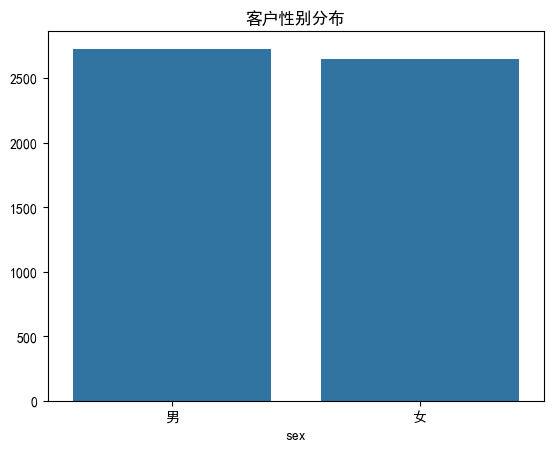

In [20]:
#性别可视化分布
sex_count=client_account["sex"].value_counts()
sns.barplot(x=sex_count.index,y=sex_count.values)
plt.title("客户性别分布")


Text(0.5, 1.0, '客户年龄分布')

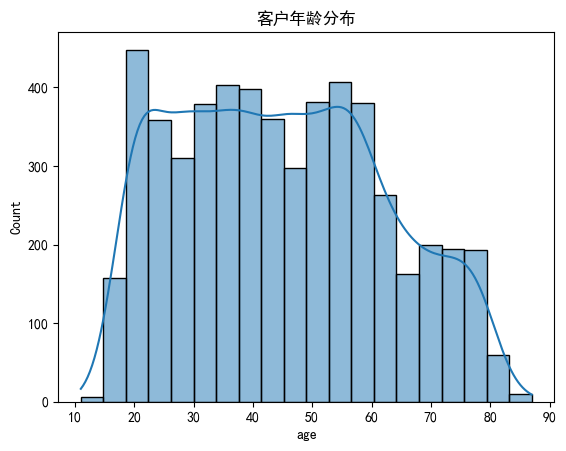

In [19]:
sns.histplot(client_account["age"],bins=20,kde=True)
plt.title("客户年龄分布")


In [24]:
trans.head()

,trans_id,account_id,date,type,operation,amount,balance,k_symbol,bank,account
0,695247,2378,1993-01-01,贷,信贷资金,700.0,700.0,NaN,NaN,NaN
1,171812,576,1993-01-01,贷,信贷资金,900.0,900.0,NaN,NaN,NaN
2,207264,704,1993-01-01,贷,信贷资金,1000.0,1000.0,NaN,NaN,NaN
3,1117247,3818,1993-01-01,贷,信贷资金,600.0,600.0,NaN,NaN,NaN
4,579373,1972,1993-01-02,贷,信贷资金,400.0,400.0,NaN,NaN,NaN


In [29]:
last_trans_date = trans.groupby('account_id')['date'].max().reset_index()
last_trans_date.head()

,account_id,date
0,1,1998-12-31
1,2,1998-12-31
2,3,1998-12-31
3,4,1998-12-31
4,5,1998-12-31


In [30]:
last_trans_date['recency_days'] = (stat_cut_date - last_trans_date['date']).dt.days

In [33]:
raw_max_date = max(trans["date"].max(), loans["date"].max())
stat_cut_date = raw_max_date + pd.Timedelta(days=1)

In [34]:
last_trans_date = trans.groupby('account_id')['date'].max().reset_index()
# 现在差值最小=1，不再是0
last_trans_date['recency_days'] = (stat_cut_date - last_trans_date['date']).dt.days

In [35]:
client_account = pd.merge(
    client_account, 
    last_trans_date[['account_id', 'recency_days']], 
    on='account_id', 
    how='left'
)

In [36]:
max_recency = client_account['recency_days'].max()
client_account['recency_days'] = client_account['recency_days'].fillna(max_recency)

In [41]:
#RFM分层
#最近一次消费间隔时间
client_account["R_rank"]=client_account["recency_days"].rank(ascending=False,method="min")
client_account["R_score"]=pd.cut(client_account["R_rank"],5,labels=[1,2,3,4,5]).astype(int)
client_account[["account_id","R_rank","R_score"]].head(3)

,account_id,R_rank,R_score
0,1,210.0,5
1,2,210.0,5
2,2,210.0,5


In [55]:
# 二维交叉5类分群函数
# 重要价值客户：近期活跃（R≥4）+ 交易频次 & 金额双高 (F+M≥8) → 核心盈利客群
# 重要发展客户：近期活跃（R≥4）+ 交易贡献低 (F+M≤5) → 潜力待培育
# 重要挽留客户：长期无交易（R≤2）+ 历史贡献极高 (F+M≥8) → 高价值流失风险，优先挽留
# 潜力普通客户：活跃度中等（R=3），交易贡献中等 → 常规存量客户
# 流失沉睡客户：长期不活跃 + 交易贡献极低 → 低价值流失预警
def rfm_5cross_segment(row):
    R = row['R_score']
    F = row['F_score']
    M = row['M_score']
    fm_sum = F + M
    
    if R >= 4 and fm_sum >= 8:
        return "重要价值客户"
    elif R >= 4 and fm_sum <= 5:
        return "重要发展客户"
    elif R <= 2 and fm_sum >= 8:
        return "重要挽留客户"
    elif R == 3:
        return "潜力普通客户"
    else:
        return "流失沉睡客户"

# 生成分群标签
client_account['RFM_segment'] = client_account.apply(rfm_5cross_segment, axis=1)

# 预览结果
client_account[['account_id','R_score','F_score','M_score','RFM_total','RFM_segment']].head(10)

,account_id,R_score,F_score,M_score,RFM_total,RFM_segment
0,1,5,3,2,10,重要发展客户
1,2,5,5,5,15,重要价值客户
2,2,5,5,5,15,重要价值客户
3,3,5,1,1,7,重要发展客户
4,3,5,1,1,7,重要发展客户
5,4,5,3,2,10,重要发展客户
6,5,5,1,1,7,重要发展客户
7,6,5,3,2,10,重要发展客户
8,7,5,2,3,10,重要发展客户
9,8,5,3,4,12,流失沉睡客户


二维交叉RFM五分客户分布：
     客户分群  客户数量  占比(%)
0  重要发展客户  2159  40.21
1  重要价值客户  1646  30.66
2  流失沉睡客户  1509  28.11
3  潜力普通客户    45   0.84
4  重要挽留客户    10   0.19


C:\Users\胡勇\AppData\Local\Temp\ipykernel_12772\2992585253.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rfm_cross_dist, x='客户分群', y='客户数量', palette='Blues_d')


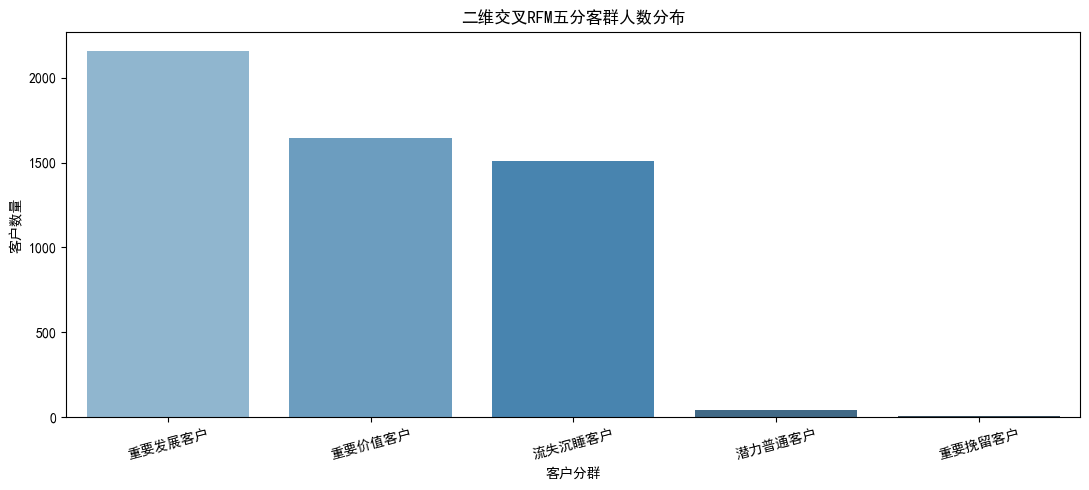

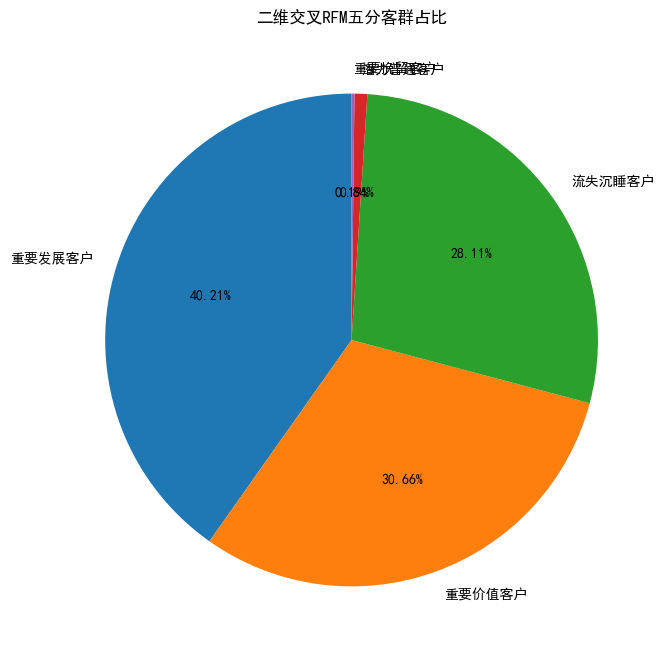


各客群RFM&基础业务指标均值：
             recency_days  trans_count  total_trans_amount    age  loan_count
RFM_segment                                                                  
流失沉睡客户               8.85       238.02          1073862.60  44.72        0.16
潜力普通客户              27.11       140.18          1130954.84  36.42        0.04
重要价值客户               1.13       372.30          2842495.78  40.97        0.26
重要发展客户               1.34       130.25           477689.25  48.05        0.07
重要挽留客户              33.90       311.50          3429497.00  40.30        0.30


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 各客群数量、占比统计
rfm_cross_dist = client_account['RFM_segment'].value_counts().reset_index()
rfm_cross_dist.columns = ['客户分群', '客户数量']
rfm_cross_dist['占比(%)'] = (rfm_cross_dist['客户数量'] / rfm_cross_dist['客户数量'].sum() * 100).round(2)
print("二维交叉RFM五分客户分布：")
print(rfm_cross_dist)

# 2. 柱状图：客户数量分布
plt.figure(figsize=(11,5))
sns.barplot(data=rfm_cross_dist, x='客户分群', y='客户数量', palette='Blues_d')
plt.title('二维交叉RFM五分客群人数分布')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('RFM交叉五分人数柱状图.png', dpi=300)
plt.show()

# 3. 饼图：客群占比
plt.figure(figsize=(8,8))
plt.pie(rfm_cross_dist['客户数量'], labels=rfm_cross_dist['客户分群'], autopct='%.2f%%', startangle=90)
plt.title('二维交叉RFM五分客群占比')
plt.savefig('RFM交叉五分占比饼图.png', dpi=300)
plt.show()

# 4. 各分群核心指标均值对比
cross_group_stats = client_account.groupby('RFM_segment').agg({
    'recency_days':'mean',
    'trans_count':'mean',
    'total_trans_amount':'mean',
    'age':'mean',
    'loan_count':'mean'
}).round(2)
print("\n各客群RFM&基础业务指标均值：")
print(cross_group_stats)
cross_group_stats.to_excel('RFM二维交叉五分指标汇总.xlsx')

In [59]:
# 1. 重要价值客户
# 特征：近期高频大额交易，贡献度最高
# 运营策略：专属信贷优惠、高等级信用卡权益、一对一理财顾问，适度放宽贷款风控门槛，优先交叉销售高收益产品。

# 2. 重要发展客户
# 特征：近期活跃但交易金额/频次偏低，有增长空间
# 运营策略：消费返现、分期免息活动，推送小额信贷、理财产品，引导提升交易规模，挖掘潜在资产需求。

# 3. 重要挽留客户
# 特征：历史交易贡献极高，但长期无交易，流失风险大
# 运营策略：主动电话回访，手续费减免、短期利率优惠挽留；限制大额新贷款审批，重点激活沉睡账户。

# 4. 潜力普通客户
# 特征：活跃度、交易贡献中等，存量基础客群
# 运营策略：常规节日营销、小额满减活动，维持账户活跃度，定期推送适配基础信贷产品。

# 5. 流失沉睡客户
# 特征：长期无交易，历史贡献极低
# 运营策略：低成本短信触达唤醒，不投入高额营销资源；贷款申请严格风控，降低授信额度。

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [65]:
rfm_features=client_account[['recency_days', 'trans_count', 'total_trans_amount']]
scaler=StandardScaler()
rfm_scaled=scaler.fit_transform(rfm_features)
inertia_list=[]
sil_score_list=[]
for k in range(2,11):
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(rfm_scaled)
    inertia_list.append(km.inertia_)
    sil_score_list.append(silhouette_score(rfm_scaled, km.labels_))
print(inertia_list)
print(sil_score_list)


[10274.400621876805, 5807.258988914258, 3990.907967591497, 3273.2011730859435, 2692.5093548658756, 2145.652703493168, 1815.1624203420556, 1577.6780574070115, 1433.8838637123536]
[0.4998314919136286, 0.5149245854002279, 0.43943323518383504, 0.4407809043672761, 0.4451091892237556, 0.4364842576569438, 0.3815176591425221, 0.37071612375108015, 0.3854257031489327]


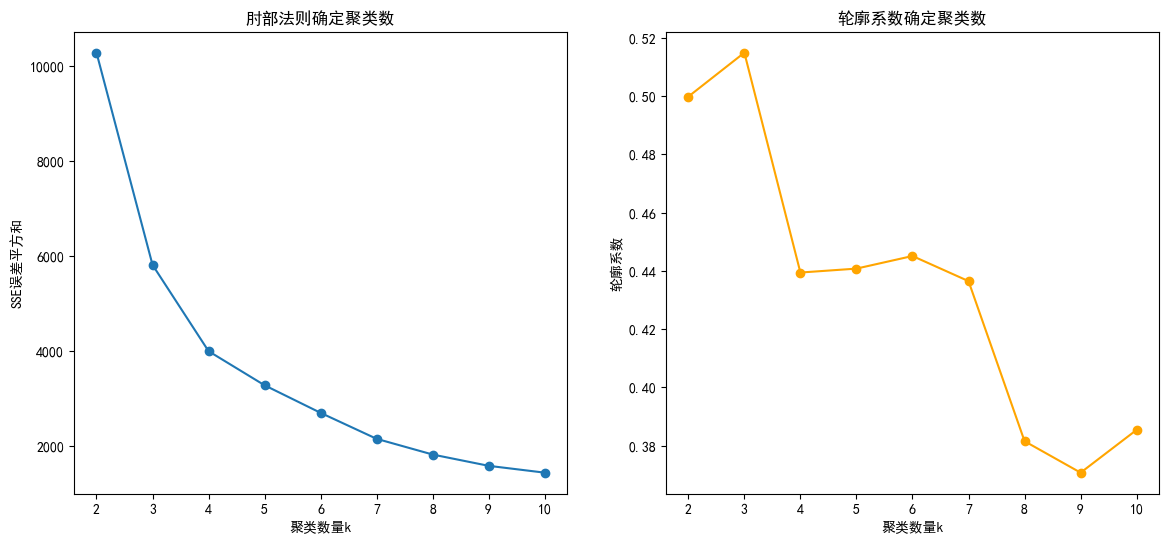

In [66]:
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.plot(range(2,11),inertia_list,marker="o")
plt.title("肘部法则确定聚类数")
plt.xlabel("聚类数量k")
plt.ylabel("SSE误差平方和")
plt.subplot(1,2,2)
plt.plot(k_range, sil_score_list, marker='o', color='orange')
plt.title('轮廓系数确定聚类数')
plt.xlabel('聚类数量k')
plt.ylabel('轮廓系数')
plt.savefig('Kmeans最优k值选择图.png', dpi=300, bbox_inches='tight')
plt.show()

In [68]:
kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
client_account["KMeans_cluster"]=kmeans.fit_predict(rfm_scaled)
client_account[["KMeans_cluster"]]

,KMeans_cluster
0,0
1,2
2,2
3,0
4,0
...,...
5364,2
5365,2
5366,2
5367,2


In [69]:
cluster_summary = client_account.groupby('KMeans_cluster').agg({
    'recency_days':'mean',
    'trans_count':'mean',
    'total_trans_amount':'mean',
    'age':'mean',
    'loan_count':'mean',
    'client_id':'count'
}).rename(columns={'client_id':'样本数量'}).round(2)
print("K-Means4类聚类指标汇总：")
print(cluster_summary)

K-Means4类聚类指标汇总：
                recency_days  trans_count  total_trans_amount    age  \
KMeans_cluster                                                         
0                       2.42       179.85           779192.56  46.63   
1                     575.14        28.57            59150.07  38.93   
2                       1.48       388.01          3035505.36  39.98   

                loan_count  样本数量  
KMeans_cluster                    
0                     0.11  3918  
1                     0.00    14  
2                     0.27  1437  


In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve

In [82]:
loans.head(3)

,loan_id,account_id,date,amount,duration,payments,status,default
0,5314,1787,1993-07-05,96396,12,8033,B,0.0
1,5316,1801,1993-07-11,165960,36,4610,A,0.0
2,6863,9188,1993-07-28,127080,60,2118,A,0.0


In [83]:
loans["default"]=loans["status"].map({"A":0,"B":0,"C":1})
loans.head(2)

C:\Users\胡勇\AppData\Local\Temp\ipykernel_12772\1964218146.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans["default"]=loans["status"].map({"A":0,"B":0,"C":1})


,loan_id,account_id,date,amount,duration,payments,status,default
0,5314,1787,1993-07-05,96396,12,8033,B,0
1,5316,1801,1993-07-11,165960,36,4610,A,0


In [77]:
loans=loans.dropna(subset=["default"])

In [81]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 637 entries, 0 to 681
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   loan_id     637 non-null    int64         
 1   account_id  637 non-null    int64         
 2   date        637 non-null    datetime64[ns]
 3   amount      637 non-null    int64         
 4   duration    637 non-null    int64         
 5   payments    637 non-null    int64         
 6   status      637 non-null    object        
 7   default     637 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 44.8+ KB


In [86]:
loan_target=loans.groupby("account_id").agg(
    default=("default","max"),
    loan_count=('loan_id','count'),
    total_loan_amount=('amount','sum'),
    avg_loan_duration=('duration','mean'),
    avg_payment=('payments','mean')
).reset_index()

In [87]:
loan_target.head(2)

,account_id,default,loan_count,total_loan_amount,avg_loan_duration,avg_payment
0,2,0,1,80952,24.0,3373.0
1,19,0,1,30276,12.0,2523.0


In [88]:
client_account.head(2)

,client_id,sex,birth_date,district_id,disp_id,account_id,type,district_id_account,frequency,date,...,recency_days,R_rank,R_score,F_rank,F_score,M_rank,M_score,RFM_total,RFM_segment,KMeans_cluster
0,1,女,1970-12-13,18,1,1,所有者,18,月结,1995-03-24,...,1,210.0,5,3059.0,3,1152.0,2,10,重要发展客户,0
1,2,男,1945-02-04,1,2,2,所有者,1,月结,1993-02-26,...,1,210.0,5,5162.0,5,4796.0,5,15,重要价值客户,2


In [89]:
model_df=pd.merge(loan_target,client_account,on="account_id",how="inner")
model_df.head(2)

,account_id,default,loan_count_x,total_loan_amount_x,avg_loan_duration_x,avg_payment_x,client_id,sex,birth_date,district_id,...,recency_days,R_rank,R_score,F_rank,F_score,M_rank,M_score,RFM_total,RFM_segment,KMeans_cluster
0,2,0,1,80952,24.0,3373.0,2,男,1945-02-04,1,...,1,210.0,5,5162.0,5,4796.0,5,15,重要价值客户,2
1,2,0,1,80952,24.0,3373.0,3,女,1940-10-09,1,...,1,210.0,5,5162.0,5,4796.0,5,15,重要价值客户,2


In [91]:
model_df.columns

Index(['account_id', 'default', 'loan_count_x', 'total_loan_amount_x',
       'avg_loan_duration_x', 'avg_payment_x', 'client_id', 'sex',
       'birth_date', 'district_id', 'disp_id', 'type', 'district_id_account',
       'frequency', 'date', 'A1', 'GDP', 'A4', 'A10', 'A11', 'A12', 'A13',
       'A14', 'A15', 'a16', 'age', 'account_open_years', 'loan_count_y',
       'total_loan_amount_y', 'avg_loan_duration_y', 'avg_payment_y',
       'default_status', 'card_count', 'max_card_age', 'card_type_count',
       'trans_count', 'total_trans_amount', 'avg_trans_amount', 'balance_avg',
       'credit_trans_count', 'debit_trans_count', 'order_count',
       'total_order_amount', 'avg_order_amount', 'recency_days', 'R_rank',
       'R_score', 'F_rank', 'F_score', 'M_rank', 'M_score', 'RFM_total',
       'RFM_segment', 'KMeans_cluster'],
      dtype='object')

In [92]:
drop_cols = ['loan_count_x','total_loan_amount_x','avg_loan_duration_x','avg_payment_x','default_status']
model_df = model_df.drop(columns=drop_cols)
model_df = model_df.rename(columns={
    'loan_count_y':'loan_count',
    'total_loan_amount_y':'total_loan_amount',
    'avg_loan_duration_y':'avg_loan_duration',
    'avg_payment_y':'avg_payment'
})
model_df = model_df.dropna()

In [93]:
model_df.head(2)

,account_id,default,client_id,sex,birth_date,district_id,disp_id,type,district_id_account,frequency,...,recency_days,R_rank,R_score,F_rank,F_score,M_rank,M_score,RFM_total,RFM_segment,KMeans_cluster
0,2,0,2,男,1945-02-04,1,2,所有者,1,月结,...,1,210.0,5,5162.0,5,4796.0,5,15,重要价值客户,2
1,2,0,3,女,1940-10-09,1,3,用户,1,月结,...,1,210.0,5,5162.0,5,4796.0,5,15,重要价值客户,2


In [94]:
X = model_df.drop(columns=['client_id','account_id','disp_id','birth_date','date','default'])
y = model_df['default']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [105]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 781
Data columns (total 43 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sex                  775 non-null    object 
 1   district_id          775 non-null    int64  
 2   type                 775 non-null    object 
 3   district_id_account  775 non-null    int64  
 4   frequency            775 non-null    object 
 5   A1                   775 non-null    int64  
 6   GDP                  775 non-null    int64  
 7   A4                   775 non-null    int64  
 8   A10                  775 non-null    float64
 9   A11                  775 non-null    int64  
 10  A12                  775 non-null    float64
 11  A13                  775 non-null    float64
 12  A14                  775 non-null    int64  
 13  A15                  775 non-null    float64
 14  a16                  775 non-null    float64
 15  age                  775 non-null    int64  


In [103]:
model_df["default"].value_counts()

default
1    489
0    286
Name: count, dtype: int64

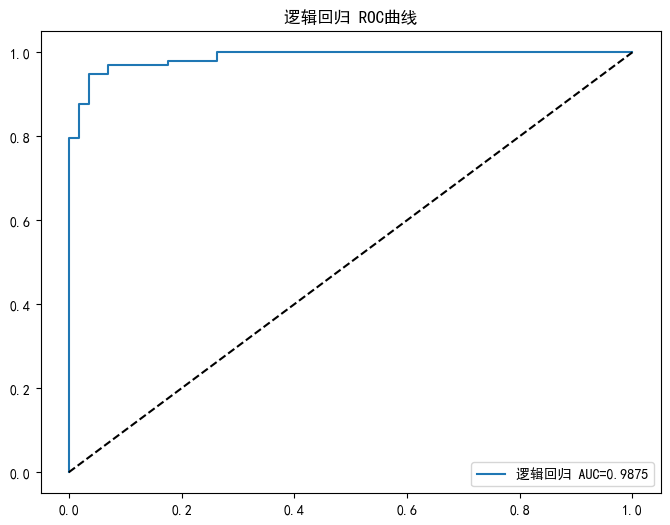

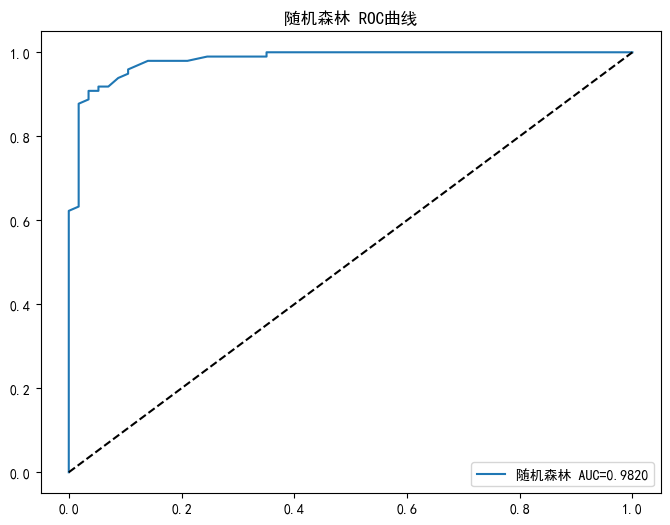

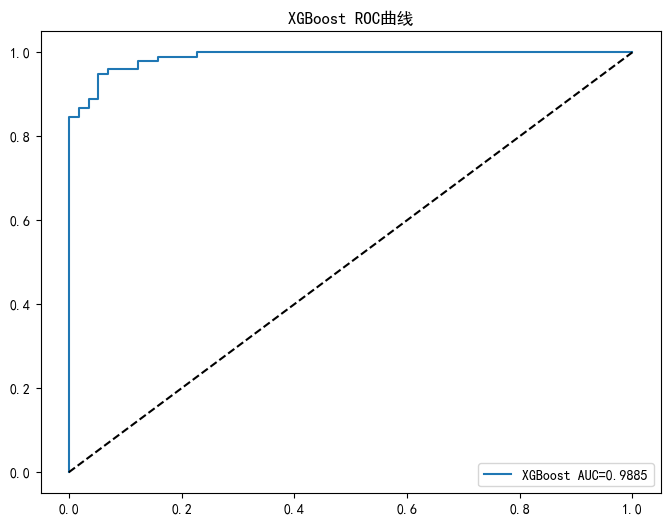

In [109]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features=X.select_dtypes(include=[np.number]).columns.tolist()
num_pipe = Pipeline([('scaler', StandardScaler())])
cat_pipe = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_features),
    ('cat', cat_pipe, cat_features)
])

# 计算XGB专用平衡权重
pos_num = sum(y_train == 1)
neg_num = sum(y_train == 0)
scale_pos = neg_num / pos_num

# 模型：全部开启类别平衡，无需采样
models = {
    '逻辑回归': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    '随机森林': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss', scale_pos_weight=scale_pos)
}
model_result_list = []
for name, model in models.items():
    full_pipe = Pipeline([('prep', preprocessor), ('model', model)])
    full_pipe.fit(X_train, y_train)
    
    y_pred = full_pipe.predict(X_test)
    y_pred_proba = full_pipe.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    model_result_list.append({
        '模型名称': name,
        '准确率': round(acc,4),
        '精确率': round(prec,4),
        '召回率': round(rec,4),
        'F1分数': round(f1,4),
        'AUC': round(auc,4)
    })
    # 绘制ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'{name} AUC={auc:.4f}')
    plt.plot([0,1],[0,1],'k--')
    plt.title(f'{name} ROC曲线')
    plt.legend()


In [110]:
eval_df = pd.DataFrame(model_result_list)
print(eval_df)


      模型名称     准确率     精确率    召回率    F1分数     AUC
0     逻辑回归  0.9548  0.9789  0.949  0.9637  0.9875
1     随机森林  0.9290  0.9394  0.949  0.9442  0.9820
2  XGBoost  0.9484  0.9688  0.949  0.9588  0.9885


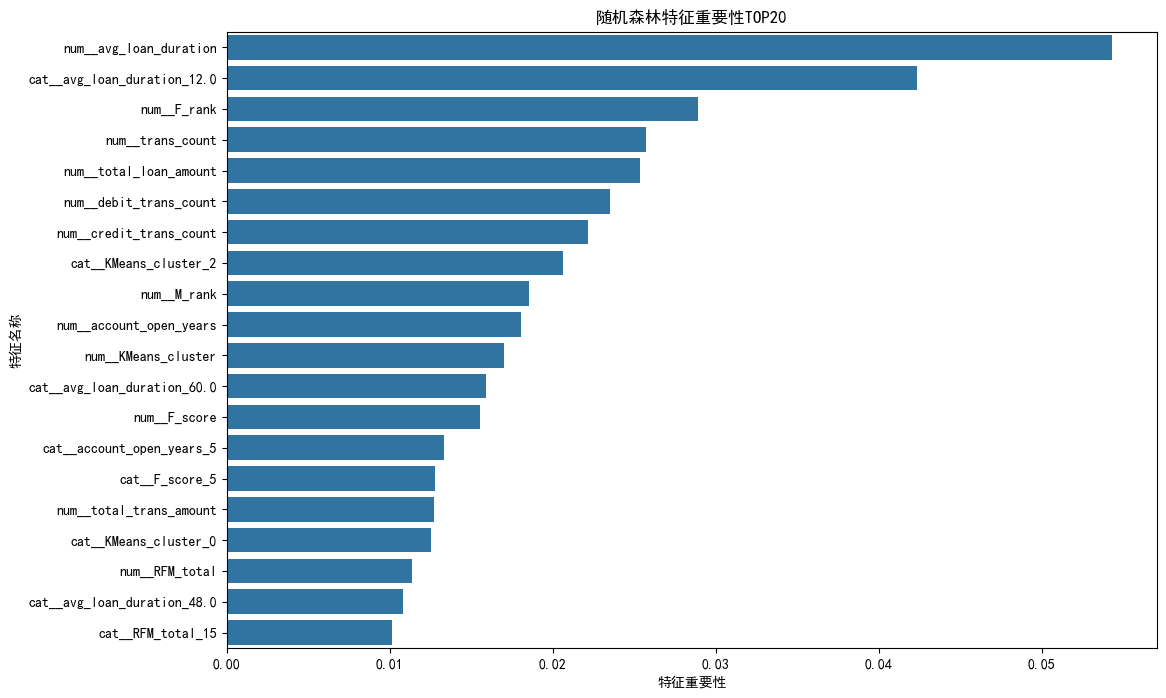

In [111]:
# 随机森林特征重要性
rf_pipe = Pipeline([('prep', preprocessor), ('model', models['随机森林'])])
rf_pipe.fit(X_train, y_train)
feature_names = preprocessor.get_feature_names_out()
feat_imp_df = pd.DataFrame({
    '特征名称': feature_names,
    '特征重要性': rf_pipe.named_steps['model'].feature_importances_
}).sort_values('特征重要性', ascending=False)

feat_imp_df.to_excel('随机森林特征重要性.xlsx', index=False)
plt.figure(figsize=(12,8))
sns.barplot(x='特征重要性', y='特征名称', data=feat_imp_df.head(20))
plt.title('随机森林特征重要性TOP20')
plt.savefig('特征重要性TOP20.png', dpi=300, bbox_inches='tight')
plt.show()